# Setup

In [1]:
!pip install -q biopython tensorflow scikit-learn seaborn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.8 MB/s eta 0:00:00


In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from collections import Counter
from Bio import SeqIO
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Carpeta donde guardar/leer los .npy y figuras
DATA_DIR = '/content/data/encoded'
FIG_DIR  = '/content/figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

---
## Carga del dataset

In [3]:
# Ajusta la ruta según dónde tengas el FASTA
FASTA_PATH = '/content/SimpleRepeatSeq_dataset.fasta'

seqs = list(SeqIO.parse(FASTA_PATH, 'fasta'))
print(f'Total de secuencias: {len(seqs)}')
seqs[:2]

Total de secuencias: 888


[SeqRecord(seq=Seq('TGCCACATACCCACCTTTATATTCTCCCCATGACAAAGCAATCATGTTTATATG...CCT'), id='mitochondrial_CR_322#no_simpleSeq#459', name='mitochondrial_CR_322#no_simpleSeq#459', description='mitochondrial_CR_322#no_simpleSeq#459', dbxrefs=[]),
 SeqRecord(seq=Seq('CCGGGATGCAGGGCTTTAACGCAGGCGTGCGCGCAACAGCAGCCGTGGTGAGAG...CGG'), id='rDNA_ITS_073#no_simpleSeq#366', name='rDNA_ITS_073#no_simpleSeq#366', description='rDNA_ITS_073#no_simpleSeq#366', dbxrefs=[])]

In [4]:
# Diagnóstico: caracteres presentes y longitudes
todos = Counter()
for s in seqs:
    todos.update(str(s.seq).upper())

print('Caracteres únicos:', sorted(todos.keys()))
print('Frecuencias:', dict(todos))

longitudes = [len(s.seq) for s in seqs]
print(f'\nLongitud min: {min(longitudes)} | max: {max(longitudes)} | promedio: {sum(longitudes)/len(longitudes):.1f}')

Caracteres únicos: ['A', 'C', 'G', 'T']
Frecuencias: {'T': 49558, 'G': 51046, 'C': 48833, 'A': 48894}

Longitud min: 100 | max: 500 | promedio: 223.3


In [5]:
# Códigos IUPAC ambiguos: todos se tratan como desconocido (0)
AMBIGUOS_IUPAC = ['N', 'R', 'Y', 'K', 'M', 'S', 'W', 'B', 'D', 'H', 'V']
MAX_LEN = max(len(s.seq) for s in seqs)
print(f'MAX_LEN para padding: {MAX_LEN}')

MAX_LEN para padding: 500


## Funciones de encoding
Valores tomados textualmente de la especificación del proyecto.

In [6]:
def normalizar_secuencia(sequence):
    """Colapsa N + todos los IUPAC ambiguos a 'N' para consistencia con los k-meros."""
    seq = sequence.upper()
    return ''.join(nt if nt in 'ACGT' else 'N' for nt in seq)

# --- Encodings posicionales 1D (valores exactos de la especificación) ---
def dax_encode(sequence):
    # A=2, C=0, G=3, T=1, N=1.5
    mapping = {'A': 2.0, 'C': 0.0, 'G': 3.0, 'T': 1.0}
    return [mapping.get(nt, 1.5) for nt in sequence.upper()]

def eiip_encode(sequence):
    # Energía de interacción electrón-ión: A=0.126, C=0.134, G=0.081, T=0.134
    mapping = {'A': 0.126, 'C': 0.134, 'G': 0.081, 'T': 0.134}
    return [mapping.get(nt, 0.0) for nt in sequence.upper()]

def complementary_encode(sequence):
    # Escala purina/pirimidina: A=2, C=-1, G=1, T=-2 (N=0)
    mapping = {'A': 2.0, 'C': -1.0, 'G': 1.0, 'T': -2.0}
    return [mapping.get(nt, 0.0) for nt in sequence.upper()]

def pad_1d(seq_codificada, max_len, pad_value=0.0):
    n = len(seq_codificada)
    if n >= max_len:
        return list(seq_codificada[:max_len])
    return list(seq_codificada) + [pad_value] * (max_len - n)

print('Funciones de encoding listas (DAX, EIIP, Complementario con valores de la especificación).')

Funciones de encoding listas (DAX, EIIP, Complementario con valores de la especificación).


## Generación de etiquetas (binario)
La clase está en el **segundo** campo del ID: `>CAG_huntington_007#simpleSeq#210`.

In [7]:
labels = [s.id.split('#')[1] for s in seqs]      # simpleSeq / no_simpleSeq
unique_labels = sorted(set(labels))               # ['no_simpleSeq', 'simpleSeq']
label_to_int = {'no_simpleSeq': 0, 'simpleSeq': 1}
y_encoded = np.array([label_to_int[lab] for lab in labels])

print('Etiquetas únicas:', unique_labels)
print('Mapeo:', label_to_int)
print(f'Shape de y: {y_encoded.shape}')
print('Distribución:', dict(zip(*np.unique(y_encoded, return_counts=True))))

np.save(f'{DATA_DIR}/y_labels.npy', y_encoded)

Etiquetas únicas: ['no_simpleSeq', 'simpleSeq']
Mapeo: {'no_simpleSeq': 0, 'simpleSeq': 1}
Shape de y: (888,)
Distribución: {np.int64(0): np.int64(444), np.int64(1): np.int64(444)}


## Generación de todos los encodings

In [8]:
# Encodings posicionales 1D (requieren padding a MAX_LEN)
def construir_posicional(func_encode, dtype=np.float32, pad_value=0.0):
    X = [pad_1d(func_encode(str(s.seq)), MAX_LEN, pad_value) for s in seqs]
    return np.array(X, dtype=dtype)

X_dax = construir_posicional(dax_encode)
np.save(f'{DATA_DIR}/X_dax.npy', X_dax)
print(f'X_dax: {X_dax.shape}')

X_complementary = construir_posicional(complementary_encode)
np.save(f'{DATA_DIR}/X_complementary.npy', X_complementary)
print(f'X_complementary: {X_complementary.shape}')

X_eiip = construir_posicional(eiip_encode)
np.save(f'{DATA_DIR}/X_eiip.npy', X_eiip)
print(f'X_eiip: {X_eiip.shape}')

X_dax: (888, 500)
X_complementary: (888, 500)
X_eiip: (888, 500)


In [9]:
from itertools import product

def _normalizar(sequence):
    return ''.join(nt if nt in 'ACGT' else 'N' for nt in sequence.upper())

def construir_kmer_counts(k, alfabeto='ACGTN'):
    """Frecuencias de k-meros normalizadas por longitud (ventana deslizante)."""
    vocab = sorted(''.join(p) for p in product(alfabeto, repeat=k))
    kmer_to_idx = {km: i for i, km in enumerate(vocab)}
    V = len(vocab)

    X = np.zeros((len(seqs), V), dtype=np.float32)
    for i, s in enumerate(seqs):
        seq = _normalizar(str(s.seq))
        n_windows = len(seq) - k + 1
        if n_windows > 0:
            for j in range(n_windows):
                km = seq[j:j+k]
                if km in kmer_to_idx:
                    X[i, kmer_to_idx[km]] += 1
            X[i] /= n_windows  # normalización por número de ventanas
    return X, V

for k in [3, 4, 6]:
    Xk, V = construir_kmer_counts(k)
    np.save(f'{DATA_DIR}/X_kmer{k}.npy', Xk)
    print(f'X_kmer{k}: {Xk.shape}  (vocabulario teórico={V}, 5^{k}={5**k})')

X_kmer3: (888, 125)  (vocabulario teórico=125, 5^3=125)
X_kmer4: (888, 625)  (vocabulario teórico=625, 5^4=625)
X_kmer6: (888, 15625)  (vocabulario teórico=15625, 5^6=15625)


In [10]:
# Verificación de archivos generados
archivos = ['X_dax', 'X_complementary', 'X_eiip', 'X_kmer3', 'X_kmer4', 'X_kmer6', 'y_labels']
print(f'{"Archivo":<22} {"Shape":<22} {"dtype":<12} {"MB":>8}')
print('-' * 70)
for a in archivos:
    path = f'{DATA_DIR}/{a}.npy'
    if os.path.exists(path):
        arr = np.load(path)
        mb = os.path.getsize(path) / (1024 * 1024)
        print(f'{a+".npy":<22} {str(arr.shape):<22} {str(arr.dtype):<12} {mb:>8.2f}')

Archivo                Shape                  dtype              MB
----------------------------------------------------------------------
X_dax.npy              (888, 500)             float32          1.69
X_complementary.npy    (888, 500)             float32          1.69
X_eiip.npy             (888, 500)             float32          1.69
X_kmer3.npy            (888, 125)             float32          0.42
X_kmer4.npy            (888, 625)             float32          2.12
X_kmer6.npy            (888, 15625)           float32         52.93
y_labels.npy           (888,)                 int64            0.01


---
# Experimentos: encoding × preprocesamiento × modelo

In [12]:
import sys
!{sys.executable} -m pip install -q scikeras

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score, f1_score)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
tf.random.set_seed(SEED)

CLASES = ['no_simpleSeq', 'simpleSeq']
N_CLS = 2

In [13]:
ENCODINGS = ['dax', 'complementary', 'eiip', 'kmer3', 'kmer4', 'kmer6']
PREPROCS  = ['raw', 'scaled', 'pca']
N_SPLITS  = 10        # CV folds (estratificada)
PCA_VAR   = 0.96      # varianza explicada mínima

def make_keras_model(n_features):
    """Red neuronal fully-connected (deep learning) para clasificación binaria."""
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_models(n_features):
    return {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', probability=True, random_state=SEED),
        'LR':  LogisticRegression(max_iter=2000, random_state=SEED),
        'LDA': LinearDiscriminantAnalysis(),
        'NB':  GaussianNB(),
        'RF':  RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
        'XGB': XGBClassifier(n_estimators=200, random_state=SEED,
                             eval_metric='logloss', verbosity=0),
        'DNN': KerasClassifier(model=make_keras_model, n_features=n_features,
                               epochs=40, batch_size=32, verbose=0, random_state=SEED),
    }

# Métricas para clasificación binaria
SCORING = {
    'accuracy':  'accuracy',
    'f1':        'f1_weighted',
    'precision': 'precision_weighted',
    'recall':    'recall_weighted',
    'auc':       'roc_auc',
}

kf_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
n_models = 8
print(f'Modelos: {n_models}  |  Encodings: {len(ENCODINGS)}  |  Preproc: {len(PREPROCS)}')
print(f'Total de combinaciones: {len(ENCODINGS)} × {len(PREPROCS)} × {n_models} = {len(ENCODINGS)*len(PREPROCS)*n_models}')

Modelos: 8  |  Encodings: 6  |  Preproc: 3
Total de combinaciones: 6 × 3 × 8 = 144


In [14]:
def build_pipeline(preproc, model):
    """scaler y PCA van dentro del Pipeline para ajustarse sólo con el train de cada fold
    (evita data leakage)."""
    steps = []
    if preproc == 'scaled':
        steps.append(('scaler', StandardScaler()))
    elif preproc == 'pca':
        steps.append(('scaler', StandardScaler()))
        steps.append(('pca', PCA(n_components=PCA_VAR, random_state=SEED)))
    steps.append(('model', model))
    return Pipeline(steps)

In [15]:
# === Bucle principal: corre todas las combinaciones con CV 10-fold ===
resultados = []
t_global = time.time()

for enc_name in ENCODINGS:
    X_enc = np.load(f'{DATA_DIR}/X_{enc_name}.npy').astype(np.float32)
    y_enc = np.load(f'{DATA_DIR}/y_labels.npy').astype(int)
    n_feat = X_enc.shape[1]
    print(f'\n=== ENCODING: {enc_name}  shape={X_enc.shape} ===')

    for preproc in PREPROCS:
        for model_name, model in build_models(n_feat).items():
            t0 = time.time()
            try:
                pipe = build_pipeline(preproc, model)
                cv_res = cross_validate(
                    pipe, X_enc, y_enc,
                    cv=kf_cv, scoring=SCORING,
                    n_jobs=-1, return_train_score=False, error_score=np.nan)

                resultados.append({
                    'Encoding':  enc_name,
                    'Preproc':   preproc,
                    'Modelo':    model_name,
                    'Accuracy':  cv_res['test_accuracy'].mean(),
                    'Acc_std':   cv_res['test_accuracy'].std(),
                    'F1':        cv_res['test_f1'].mean(),
                    'Precision': cv_res['test_precision'].mean(),
                    'Recall':    cv_res['test_recall'].mean(),
                    'AUC':       cv_res['test_auc'].mean(),
                    'AUC_std':   cv_res['test_auc'].std(),
                    'Tiempo_s':  cv_res['fit_time'].mean() + cv_res['score_time'].mean(),
                    'N_features': n_feat,
                })
                dt = time.time() - t0
                print(f'  [{preproc:7s}] {model_name:4s}  '
                      f'Acc={cv_res["test_accuracy"].mean():.3f}  '
                      f'F1={cv_res["test_f1"].mean():.3f}  '
                      f'AUC={cv_res["test_auc"].mean():.3f}  ({dt:.1f}s)')
            except Exception as e:
                print(f'  [{preproc:7s}] {model_name:4s}  ERROR: {str(e)[:80]}')
                resultados.append({
                    'Encoding': enc_name, 'Preproc': preproc, 'Modelo': model_name,
                    'Accuracy': np.nan, 'Acc_std': np.nan, 'F1': np.nan,
                    'Precision': np.nan, 'Recall': np.nan,
                    'AUC': np.nan, 'AUC_std': np.nan,
                    'Tiempo_s': np.nan, 'N_features': n_feat,
                })

print(f'\n=== Tiempo total: {(time.time()-t_global)/60:.1f} min ===')

df_res = pd.DataFrame(resultados)
df_res.to_csv(f'{DATA_DIR}/resultados_experimento.csv', index=False)
print(f'Resultados guardados en {DATA_DIR}/resultados_experimento.csv')


=== ENCODING: dax  shape=(888, 500) ===
  [raw    ] KNN   Acc=0.554  F1=0.442  AUC=0.660  (3.4s)
  [raw    ] SVM   Acc=0.974  F1=0.974  AUC=0.997  (5.6s)
  [raw    ] LR    Acc=0.785  F1=0.783  AUC=0.844  (0.9s)
  [raw    ] LDA   Acc=0.689  F1=0.680  AUC=0.616  (1.0s)
  [raw    ] NB    Acc=0.677  F1=0.646  AUC=0.681  (0.2s)
  [raw    ] RF    Acc=0.984  F1=0.984  AUC=0.999  (5.0s)
  [raw    ] XGB   Acc=0.987  F1=0.987  AUC=0.999  (3.8s)
  [raw    ] DNN   Acc=nan  F1=nan  AUC=nan  (125.0s)
  [scaled ] KNN   Acc=0.623  F1=0.561  AUC=0.720  (0.4s)
  [scaled ] SVM   Acc=0.964  F1=0.964  AUC=0.993  (5.7s)
  [scaled ] LR    Acc=0.786  F1=0.784  AUC=0.845  (0.7s)
  [scaled ] LDA   Acc=0.687  F1=0.677  AUC=0.613  (0.9s)
  [scaled ] NB    Acc=0.672  F1=0.641  AUC=0.676  (0.2s)
  [scaled ] RF    Acc=0.985  F1=0.985  AUC=0.999  (5.8s)
  [scaled ] XGB   Acc=0.987  F1=0.987  AUC=0.999  (3.2s)
  [scaled ] DNN   Acc=nan  F1=nan  AUC=nan  (72.4s)
  [pca    ] KNN   Acc=0.626  F1=0.566  AUC=0.755  (1.0s)

---
## Tabla comparativa encoding × modelo

In [16]:
# Tabla completa, ordenada por AUC
df_show = df_res.copy()
for c in ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC', 'Acc_std', 'AUC_std', 'Tiempo_s']:
    df_show[c] = df_show[c].round(4)
df_show.sort_values('AUC', ascending=False).head(20)

,Encoding,Preproc,Modelo,Accuracy,Acc_std,F1,Precision,Recall,AUC,AUC_std,Tiempo_s,N_features
109,kmer4,scaled,RF,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,1.0069,625
112,kmer4,pca,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.2226,625
114,kmer4,pca,LR,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.2464,625
101,kmer4,raw,RF,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,1.3115,625
104,kmer4,scaled,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0398,625
105,kmer4,scaled,SVM,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.7913,625
99,kmer4,raw,LDA,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.2093,625
97,kmer4,raw,SVM,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.1450,625
96,kmer4,raw,KNN,1.0000,0.0000,1.0000,1.0000,1.0000,1.0,0.0,0.0302,625
93,kmer3,pca,RF,0.9989,0.0034,0.9989,0.9989,0.9989,1.0,0.0,1.3371,125


In [17]:
# Pivot principal: filas=Modelo, columnas=(Encoding, Preproc), valores=AUC
pivot_auc = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='AUC')
pivot_acc = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='Accuracy')
pivot_f1  = df_res.pivot_table(index='Modelo', columns=['Encoding', 'Preproc'], values='F1')
print('AUC promedio por combinación (CV 10-fold):')
pivot_auc.round(3)

AUC promedio por combinación (CV 10-fold):


Encoding complementary                  dax                 eiip         \
Preproc            pca    raw scaled    pca    raw scaled    pca    raw   
Modelo                                                                    
KNN              0.503  0.500  0.500  0.755  0.660  0.720  0.835  0.886   
LDA              0.701  0.553  0.553  0.905  0.616  0.613  0.914  0.604   
LR               0.645  0.601  0.590  0.878  0.844  0.845  0.918  0.910   
NB               0.915  0.694  0.689  0.976  0.681  0.676  1.000  0.696   
RF               0.995  0.999  0.999  0.997  0.999  0.999  0.999  0.994   
SVM              0.993  1.000  0.992  0.993  0.997  0.993  0.976  0.876   
XGB              0.998  0.999  0.999  0.997  0.999  0.999  0.998  0.997   

Encoding        kmer3               kmer4                kmer6                
Preproc  scaled   pca    raw scaled   pca    raw scaled    pca    raw scaled  
Modelo                                                                        
KNN       0.814   1.0  1.000    1.0   1.0  1.000    1.0  0.500  1.000  0.500  
LDA       0.604   1.0  1.000    1.0   1.0  1.000    1.0  1.000  0.965  0.965  
LR        0.906   1.0  0.911    1.0   1.0  0.996    1.0  1.000  1.000  1.000  
NB        0.692   1.0  1.000    1.0   1.0  1.000    1.0  0.565  0.677  0.677  
RF        0.994   1.0  1.000    1.0   1.0  1.000    1.0  1.000  1.000  1.000  
SVM       0.975   1.0  1.000    1.0   1.0  1.000    1.0  1.000  1.000  1.000  
XGB       0.997   1.0  1.000    1.0   1.0  1.000    1.0  1.000  0.995  0.995

### Figura 1 — Heatmap comparativo (AUC / Accuracy / F1)

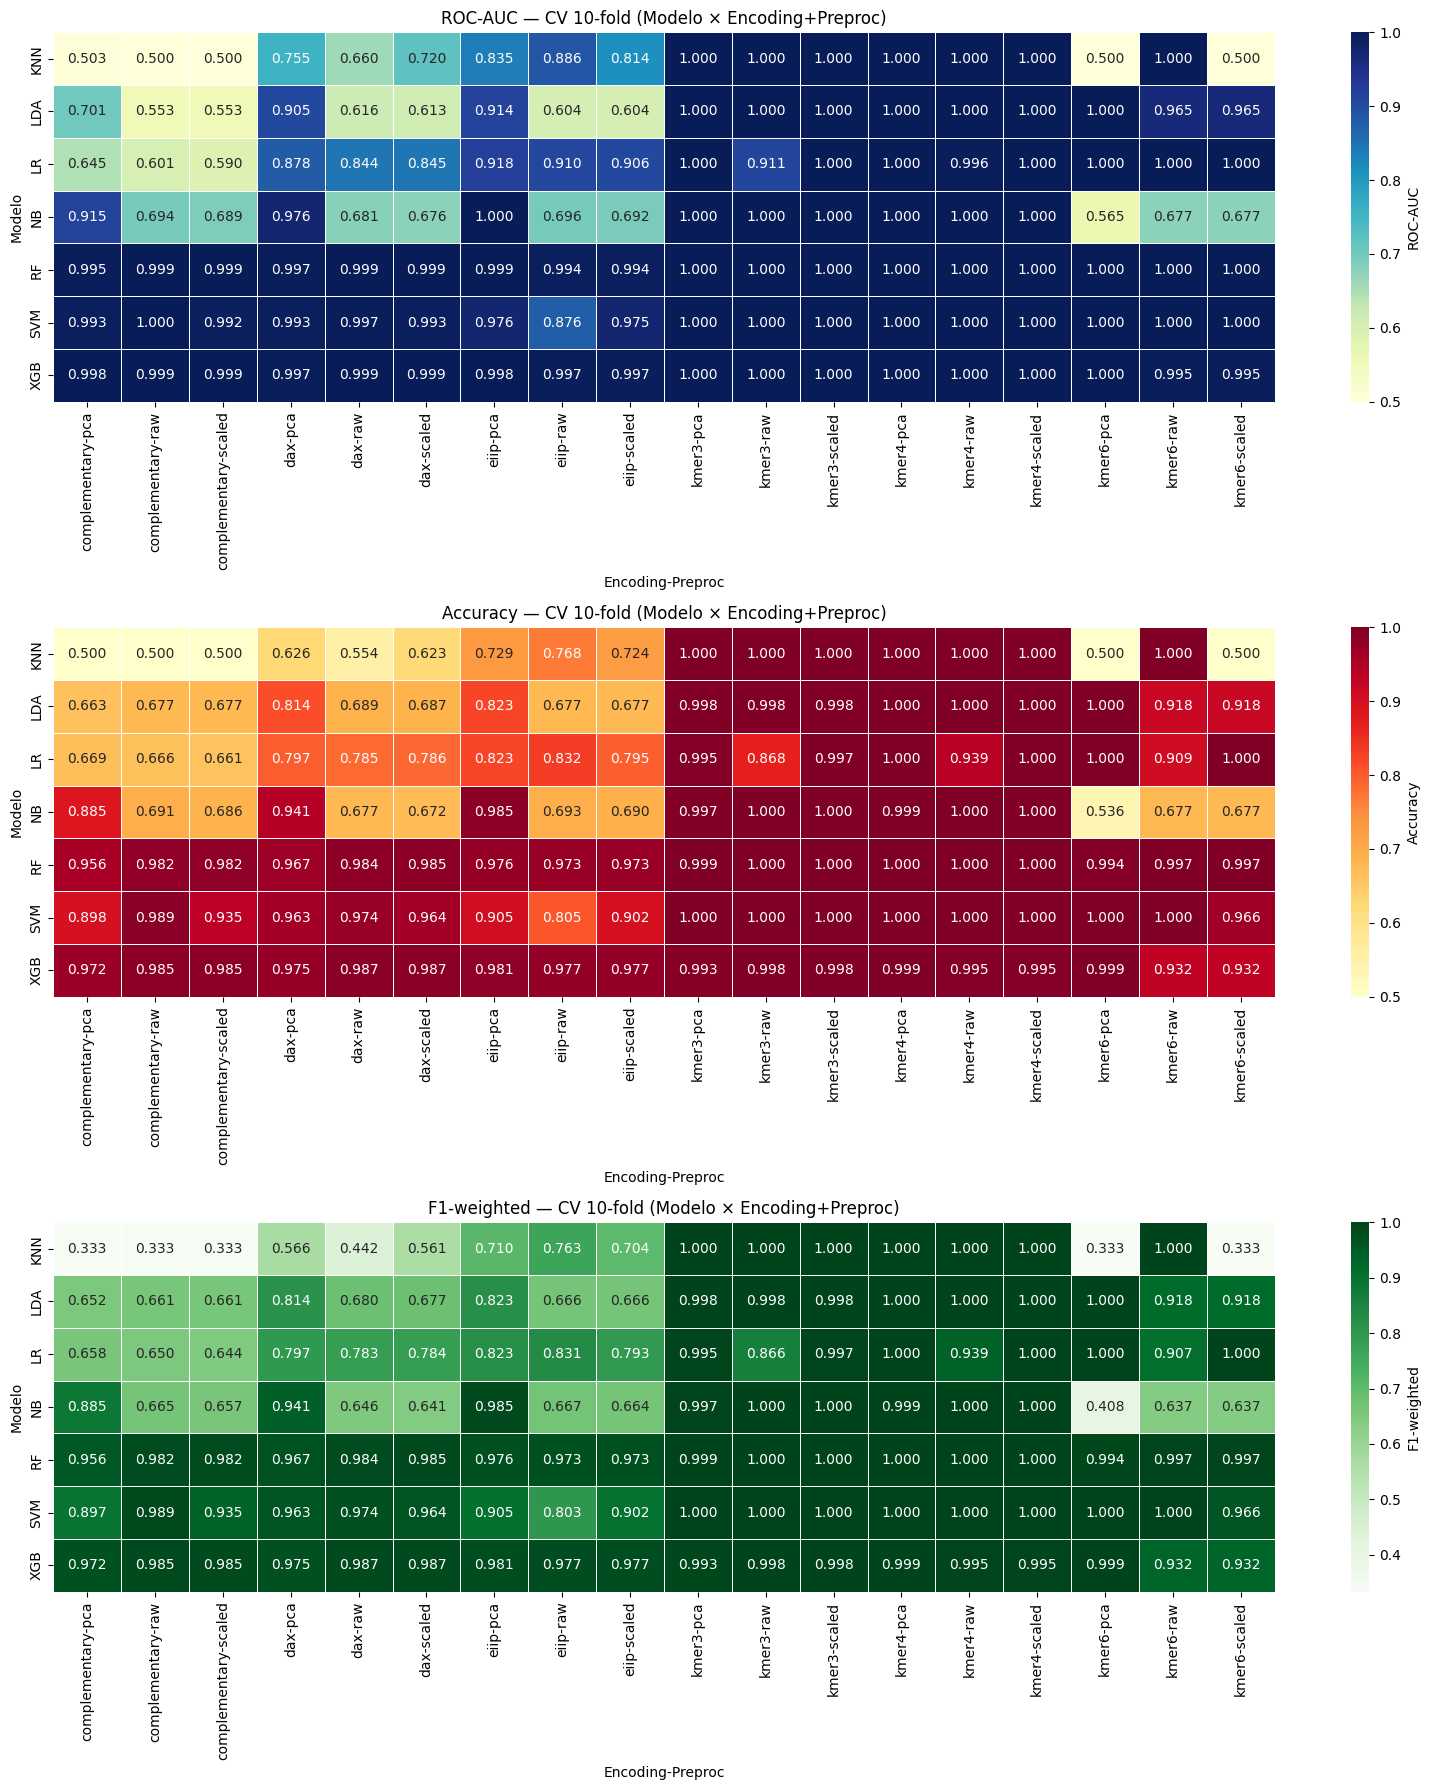

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
for ax, pivot, title, cmap in zip(
    axes,
    [pivot_auc, pivot_acc, pivot_f1],
    ['ROC-AUC', 'Accuracy', 'F1-weighted'],
    ['YlGnBu', 'YlOrRd', 'Greens']
):
    sn.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, ax=ax,
               cbar_kws={'label': title}, linewidths=0.5)
    ax.set_title(f'{title} — CV {N_SPLITS}-fold (Modelo × Encoding+Preproc)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_heatmap_comparativo.png', dpi=200, bbox_inches='tight')
plt.show()

### Rankings: mejor encoding, modelo y preprocesamiento

In [19]:
top10 = df_res.dropna(subset=['AUC']).sort_values('AUC', ascending=False).head(10)
print('TOP 10 combinaciones por AUC:')
display(top10[['Modelo', 'Encoding', 'Preproc', 'Accuracy', 'F1',
               'Precision', 'Recall', 'AUC', 'Tiempo_s', 'N_features']].round(4))

print('\nAUC por encoding:')
display(df_res.groupby('Encoding')['AUC'].agg(['mean', 'std', 'max']).round(4).sort_values('mean', ascending=False))
print('\nAUC por modelo:')
display(df_res.groupby('Modelo')['AUC'].agg(['mean', 'std', 'max']).round(4).sort_values('mean', ascending=False))
print('\nAUC por preprocesamiento:')
display(df_res.groupby('Preproc')['AUC'].agg(['mean', 'std', 'max']).round(4).sort_values('mean', ascending=False))

TOP 10 combinaciones por AUC:


,Modelo,Encoding,Preproc,Accuracy,F1,Precision,Recall,AUC,Tiempo_s,N_features
109,RF,kmer4,scaled,1.0000,1.0000,1.0000,1.0000,1.0,1.0069,625
112,KNN,kmer4,pca,1.0000,1.0000,1.0000,1.0000,1.0,0.2226,625
114,LR,kmer4,pca,1.0000,1.0000,1.0000,1.0000,1.0,0.2464,625
101,RF,kmer4,raw,1.0000,1.0000,1.0000,1.0000,1.0,1.3115,625
104,KNN,kmer4,scaled,1.0000,1.0000,1.0000,1.0000,1.0,0.0398,625
105,SVM,kmer4,scaled,1.0000,1.0000,1.0000,1.0000,1.0,0.7913,625
99,LDA,kmer4,raw,1.0000,1.0000,1.0000,1.0000,1.0,0.2093,625
97,SVM,kmer4,raw,1.0000,1.0000,1.0000,1.0000,1.0,0.1450,625
96,KNN,kmer4,raw,1.0000,1.0000,1.0000,1.0000,1.0,0.0302,625
93,RF,kmer3,pca,0.9989,0.9989,0.9989,0.9989,1.0,1.3371,125



AUC por encoding:


,mean,std,max
Encoding,,,
kmer4,0.9998,0.0010,1.0000
kmer3,0.9957,0.0195,1.0000
kmer6,0.8971,0.1841,1.0000
eiip,0.8850,0.1315,0.9997
dax,0.8640,0.1487,0.9993
complementary,0.7818,0.2106,0.9997



AUC por modelo:


,mean,std,max
Modelo,,,
RF,0.9986,0.0022,1.0
XGB,0.9985,0.0016,1.0
SVM,0.9886,0.0292,1.0
LR,0.8913,0.1405,1.0
LDA,0.8329,0.1905,1.0
NB,0.8300,0.1661,1.0
KNN,0.7874,0.2117,1.0
DNN,NaN,NaN,NaN



AUC por preprocesamiento:


,mean,std,max
Preproc,,,
pca,0.9276,0.1409,1.0
raw,0.8964,0.1593,1.0
scaled,0.8878,0.1707,1.0


---
## Evaluación detallada de la mejor configuración
Re-entrena la mejor combinación con predicciones *out-of-fold* (`cross_val_predict`) para construir curva ROC, matriz de confusión y classification report **sin data leakage**.

In [20]:
from sklearn.model_selection import cross_val_predict

best = df_res.dropna(subset=['AUC']).sort_values('AUC', ascending=False).iloc[0]
BEST_ENC, BEST_PRE, BEST_MOD = best['Encoding'], best['Preproc'], best['Modelo']
print(f'Mejor configuración: {BEST_MOD} | encoding={BEST_ENC} | preproc={BEST_PRE} | AUC={best["AUC"]:.4f}')

X_best = np.load(f'{DATA_DIR}/X_{BEST_ENC}.npy').astype(np.float32)
y_best = np.load(f'{DATA_DIR}/y_labels.npy').astype(int)

pipe_best = build_pipeline(BEST_PRE, build_models(X_best.shape[1])[BEST_MOD])
y_pred = cross_val_predict(pipe_best, X_best, y_best, cv=kf_cv, n_jobs=-1)
y_proba = cross_val_predict(pipe_best, X_best, y_best, cv=kf_cv, n_jobs=-1,
                            method='predict_proba')[:, 1]

print('\nClassification report (mejor modelo, out-of-fold):')
print(classification_report(y_best, y_pred, target_names=CLASES, digits=4))

Mejor configuración: RF | encoding=kmer4 | preproc=scaled | AUC=1.0000

Classification report (mejor modelo, out-of-fold):
              precision    recall  f1-score   support

no_simpleSeq     1.0000    1.0000    1.0000       444
   simpleSeq     1.0000    1.0000    1.0000       444

    accuracy                         1.0000       888
   macro avg     1.0000    1.0000    1.0000       888
weighted avg     1.0000    1.0000    1.0000       888



### Figura 2 — Matriz de confusión (mejor modelo)

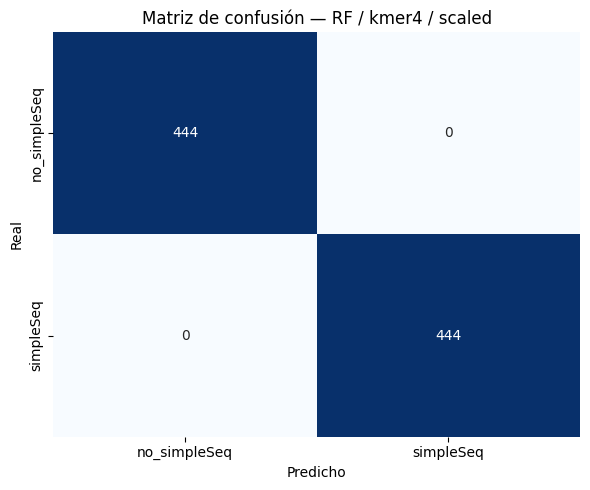

In [21]:
cm = confusion_matrix(y_best, y_pred)
plt.figure(figsize=(6, 5))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=CLASES, yticklabels=CLASES, cbar=False)
plt.title(f'Matriz de confusión — {BEST_MOD} / {BEST_ENC} / {BEST_PRE}')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_confusion_best.png', dpi=200, bbox_inches='tight')
plt.show()

### Figura 3 — Curvas ROC + AUC
Para cada encoding se elige su mejor modelo (preproc fijo en el mejor global) y se traza su curva ROC con predicciones out-of-fold.

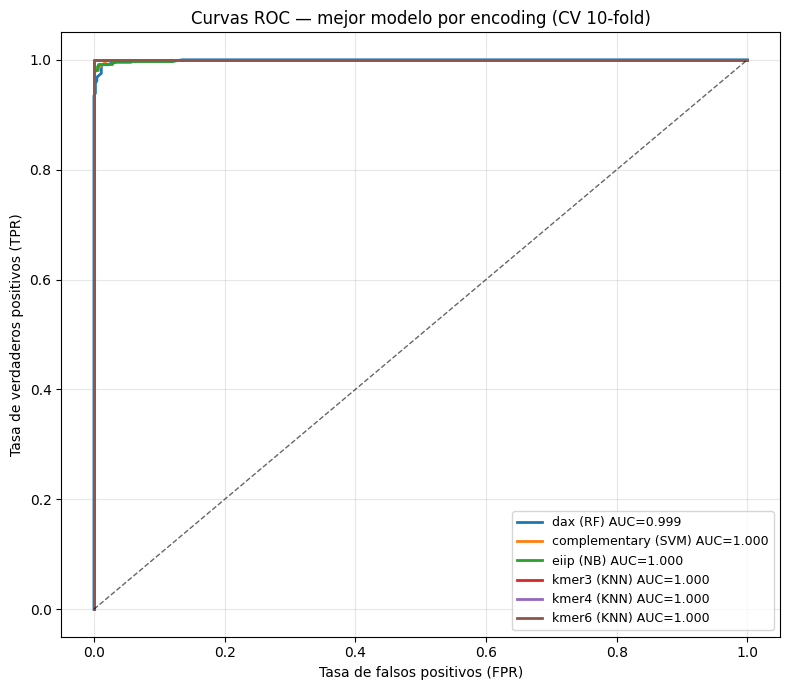

In [22]:
plt.figure(figsize=(8, 7))

for enc_name in ENCODINGS:
    # mejor modelo para este encoding (cualquier preproc)
    sub = df_res[(df_res['Encoding'] == enc_name)].dropna(subset=['AUC'])
    if sub.empty:
        continue
    row = sub.sort_values('AUC', ascending=False).iloc[0]
    Xe = np.load(f'{DATA_DIR}/X_{enc_name}.npy').astype(np.float32)
    ye = np.load(f'{DATA_DIR}/y_labels.npy').astype(int)
    pipe = build_pipeline(row['Preproc'], build_models(Xe.shape[1])[row['Modelo']])
    proba = cross_val_predict(pipe, Xe, ye, cv=kf_cv, n_jobs=-1,
                              method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(ye, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2,
             label=f'{enc_name} ({row["Modelo"]}) AUC={roc_auc:.3f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curvas ROC — mejor modelo por encoding (CV 10-fold)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_roc_por_encoding.png', dpi=200, bbox_inches='tight')
plt.show()

### Matrices de confusión + classification report de todos los modelos (mejor encoding)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.

----- KNN (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.000     1.000       888
weighted avg      1.000     1.000     1.000       888


----- SVM (kmer4/scaled) -----
              precision    recall  f1-score   support

no_simpleSeq      1.000     1.000     1.000       444
   simpleSeq      1.000     1.000     1.000       444

    accuracy                          1.000       888
   macro avg      1.000     1.

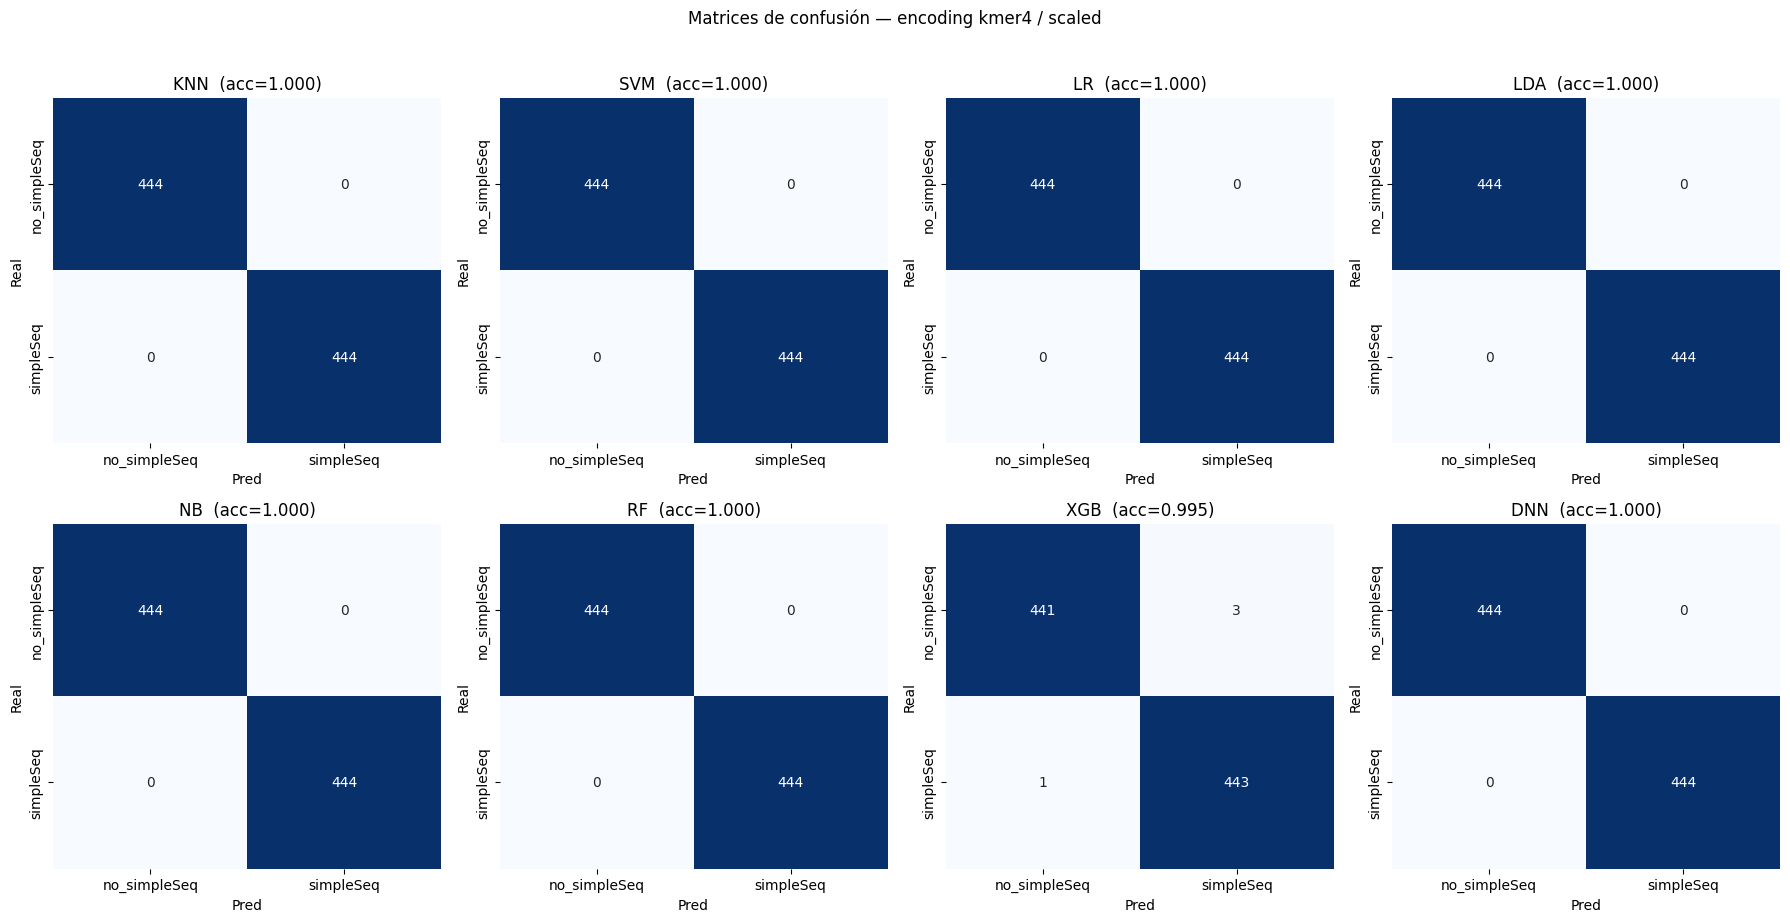

In [24]:
import sys
!{sys.executable} -m pip install -q --upgrade scikit-learn

Xe = np.load(f'{DATA_DIR}/X_{BEST_ENC}.npy').astype(np.float32)
ye = np.load(f'{DATA_DIR}/y_labels.npy').astype(int)

modelos = list(build_models(Xe.shape[1]).keys())
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, mname in zip(axes, modelos):
    pipe = build_pipeline(BEST_PRE, build_models(Xe.shape[1])[mname])
    yp = cross_val_predict(pipe, Xe, ye, cv=kf_cv, n_jobs=-1)
    cm = confusion_matrix(ye, yp)
    acc = accuracy_score(ye, yp)
    sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=CLASES, yticklabels=CLASES, ax=ax)
    ax.set_title(f'{mname}  (acc={acc:.3f})')
    ax.set_xlabel('Pred'); ax.set_ylabel('Real')
    print(f'\n----- {mname} ({BEST_ENC}/{BEST_PRE}) -----')
    print(classification_report(ye, yp, target_names=CLASES, digits=3))

plt.suptitle(f'Matrices de confusión — encoding {BEST_ENC} / {BEST_PRE}', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_cm_todos_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

### Figura 4 — Tiempo de entrenamiento vs dimensionalidad

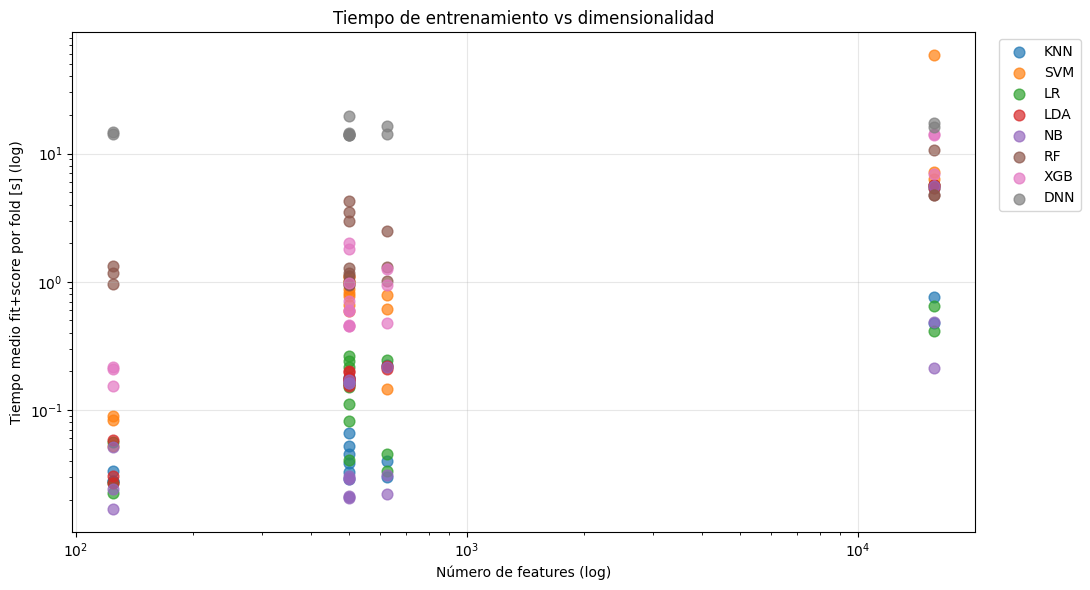

In [25]:
fig, ax = plt.subplots(figsize=(11, 6))
for modelo in df_res['Modelo'].unique():
    sub = df_res[df_res['Modelo'] == modelo].dropna(subset=['Tiempo_s'])
    ax.scatter(sub['N_features'], sub['Tiempo_s'], label=modelo, s=60, alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Número de features (log)')
ax.set_ylabel('Tiempo medio fit+score por fold [s] (log)')
ax.set_title('Tiempo de entrenamiento vs dimensionalidad')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_tiempo_vs_features.png', dpi=200, bbox_inches='tight')
plt.show()

In [26]:
import joblib
os.makedirs('/content/models', exist_ok=True)

X_full = np.load(f'{DATA_DIR}/X_{BEST_ENC}.npy').astype(np.float32)
y_full = np.load(f'{DATA_DIR}/y_labels.npy').astype(int)

final_pipe = build_pipeline(BEST_PRE, build_models(X_full.shape[1])[BEST_MOD])
final_pipe.fit(X_full, y_full)

meta = {'encoding': BEST_ENC, 'preproc': BEST_PRE, 'modelo': BEST_MOD,
        'max_len': MAX_LEN, 'clases': CLASES, 'label_to_int': label_to_int}
joblib.dump({'pipeline': final_pipe, 'meta': meta}, '/content/models/best_model.pkl')
print('Modelo guardado en /content/models/best_model.pkl')
print('Metadatos:', meta)

Modelo guardado en /content/models/best_model.pkl
Metadatos: {'encoding': 'kmer4', 'preproc': 'scaled', 'modelo': 'RF', 'max_len': 500, 'clases': ['no_simpleSeq', 'simpleSeq'], 'label_to_int': {'no_simpleSeq': 0, 'simpleSeq': 1}}
